## TCG ML PRIMER ##

**Contents:**

Helloooooo analysts. Below is a breakdown of what you will learn through completing this primer, the fundamental Data Science - Machine Learning process, and how this will prepare you to build a model for a real client.

---

# Table of Contents
## 1. Problem definition
What we'll do here: clearly frame the business/data question and pick the prediction target and evaluation metric.
What you'll learn: how to translate a real-world ask into a supervised learning task and choose a sensible metric.
1. predict Churn (binary: 0 = stayed, 1 = churned) from customer account and service features
2. target: Churn, metric: accuracy

---

## 2. Load data & missing values
What we'll do here: load the dataset and quickly summarize where values are missing so we know what to clean.
What you'll learn: practical data loading and basic missing-value checks.
1. dataset loaded (customerID, gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn)
2. missing summary: TotalCharges has blank strings for brand-new customers (~11 rows)

---

## 3. Exploratory Data Analysis (EDA)
What we'll do here: look at distributions and class balance to spot patterns and potential predictors.
What you'll learn: how to find signal, spot class imbalance, and surface relationships that inform features.
1. inspect distributions for tenure, MonthlyCharges, TotalCharges
2. class distribution for Churn (~26% churned, ~74% stayed) — class imbalance!
3. identify features that look predictive of churn

---

## 4. Data cleaning
What we'll do here: tidy up obvious issues — fix TotalCharges type, encode the target, drop the ID column.
What you'll learn: pragmatic cleaning choices that keep useful rows and prepare data for modeling.
1. drop customerID (identifier, not a predictor)
2. convert Churn to binary (Yes → 1, No → 0)
3. handle TotalCharges NaN (~11 rows) that came from blank strings

---

## 5. Feature engineering
What we'll do here: create a useful derived feature from existing numeric columns.
What you'll learn: how to combine existing variables to capture relationships the model might not see on its own.
1. engineered avg_monthly_charges = TotalCharges / (tenure + 1) — captures lifetime spend rate
2. final feature list: tenure, MonthlyCharges, TotalCharges, SeniorCitizen, avg_monthly_charges, gender, Partner, Dependents, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod

---

## 6. Preprocessing pipeline
What we'll do here: define consistent transformations for numeric and categorical inputs using sklearn pipelines.
What you'll learn: why pipelines and ColumnTransformer keep preprocessing reproducible and tidy.
1. numeric: median imputer + StandardScaler
2. categorical: most frequent imputer + OneHotEncoder (handle_unknown='ignore')
3. ColumnTransformer + Pipeline usage

---

## 7. Train / test split
What we'll do here: create a held-out test set and stratify so label proportions stay consistent.
What you'll learn: why stratified splits matter for classification and how to pick train/test sizes.
1. stratified split on Churn
2. y_train / y_test sizes and why we stratify

---

## 8. Model selection & training
What we'll do here: fit a few baseline and tree-based classifiers so we can compare performance.
What you'll learn: how to compare different algorithms with the same pipeline and CV approach.
1. trained and compared: Logistic Regression, Decision Tree, Random Forest, Extra Trees, Gradient Boosting, HistGradientBoosting
2. used cross-validation (StratifiedKFold, n_splits=5) to compare mean CV accuracy

---

## 9. Cross-validation results
What we'll do here: summarize CV accuracy per model and pick promising candidates to tune.
What you'll learn: how to read mean/std CV scores and choose models for tuning.
1. cv scores and cv_results_df showing mean/std per model

---

## 10. Hyperparameter tuning
What we'll do here: run GridSearchCV on the chosen model to find better hyperparameters.
What you'll learn: how to set up param grids, use stratified CV, and select best params by the chosen metric.
1. GridSearchCV (StratifiedKFold, scoring='accuracy') over RandomForest params (n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features)

---

## 11. Final model & evaluation
What we'll do here: train the final pipeline with the tuned params and evaluate on the test set.
What you'll learn: how to report final test metrics and collect predictions for analysis.
1. selected final_model (RandomForest pipeline with tuned params)
2. test set evaluation: test_accuracy and results_df

---

## 12. Model interpretation & error analysis
What we'll do here: inspect feature importances and common mispredictions to understand model behavior.
What you'll learn: how to extract actionable insights from importances and analyze errors to guide next steps.
1. feature importances (importance_df) — Contract, tenure, MonthlyCharges are expected top drivers
2. errors dataframe: inspect which churned customers the model missed

---

## 13. Next steps / communication
What we'll do here: outline practical recommendations and deployment/validation next steps you can present to the client.
What you'll learn: how to convert model results into clear, client-friendly actions and future experiments.
1. translate findings into plain English and a slide deck for the client
2. suggestions: target high-risk customers with retention offers, explore customer lifetime value, deploy model for real-time churn scoring

---


# STEP 0: Imports # 

*These are the imports you should need to complete this primer, you will soon see what each of these is used for and why they are necessary to create a machine learning model*


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    ExtraTreesClassifier
)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## STEP 1: Question ##

**TODO: Come up with a meaningful data science question + pick a dataset!**

Kaggle has a bunch of open source (ie open for public use) datasets for you to choose from here: https://www.kaggle.com/datasets pick one that speaks to you. I went with the IBM Telco Customer Churn dataset: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

We want to answer a certain question about the data we are being given. Think about what you want to find out about the data you are looking at. If a business were to give you this data and they wanted to improve something about how they were running, what question would they ask? Depending on the dataset, the range of analysis you could do or questions you could ask is infinite, so think about what the data could actually mean.

Example: You are given a dataset containing all of the orders (and the necessary info about them ie time place, order placed by who, order contents, nutritional info, etc) that were made at Audrey's in Geisel during finals week, meaningful data science questions would include →

- Does time of day affect how much caffeine people get in their drinks?

- Are students more likely to order unhealthy foods at night?

- Can we predict what someone will order based on the time of day?

For the Telco dataset, the business question is: **Can we predict whether a customer will churn based on their account and service information?** This is useful because if a telecom company knows in advance which customers are likely to leave, they can proactively offer them discounts or better plans to keep them.

- **Dataset:** IBM Telco Customer Churn
- **Question:** Can we predict whether a customer will churn?
- **Target column:** Churn (Yes / No → binary 0 / 1)
- **Metric:** accuracy

Once you come up with a question, start brainstorming what columns in your dataset might help you answer it!!


## STEP 2: Loading the Dataset ## 

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
# TotalCharges is stored as a string for new customers -- convert to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


## STEP 3: EDA ## 
First take a good look at your dataset: 
- What columns are there? 
- What does each column tell us? 
- Which columns relate to our problem/question? 
- Are any columns unnecessary? If so, what do we do with them? 


*Below are some common pandas methods to gain more information about your dataset without looking through each and every row/column!*

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [5]:
df.columns


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [6]:
df.iloc[0, 0]


'7590-VHVEG'

In [7]:
df.iloc[0, 1]


'Female'

Here we can see our columns describe customer demographics (gender, SeniorCitizen, Partner, Dependents), account info (tenure, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges), and services (PhoneService, MultipleLines, InternetService, and various add-ons). Going back to our original question of: "Can we predict whether a customer will churn?" what columns do you think are relevant here?


Answer: Most columns are relevant here! The ones I think will matter most are **tenure** (customers who have been around longer probably churn less), **Contract** (month-to-month customers have less commitment so are more likely to leave), **MonthlyCharges** and **TotalCharges** (higher bills might push customers away), and service features like **InternetService** and add-ons (more services = more value = less churn). The **customerID** column is NOT useful since it is just a unique identifier and contains no predictive information.


### Lets explore a little more about this data ###

Specifically let's look at:

1. How many customers churned vs stayed?
2. Are some values missing? If so, where? What do we do with them?
3. What types of values are we seeing in each column?


Below are some useful EDA techniques: 

In [8]:
print(df.head())


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [9]:
print(df.sample(5))


      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
1792  8401-EMUWF    Male              0     Yes        Yes      42   
418   0578-SKVMF  Female              0     Yes        Yes      22   
2878  0428-IKYCP    Male              0     Yes         No      22   
3928  4647-MUZON  Female              0     Yes         No      18   
3350  7663-RGWBC    Male              0      No         No       1   

     PhoneService MultipleLines InternetService OnlineSecurity  ...  \
1792          Yes           Yes             DSL            Yes  ...   
418           Yes            No     Fiber optic             No  ...   
2878          Yes            No     Fiber optic             No  ...   
3928          Yes            No     Fiber optic             No  ...   
3350          Yes            No             DSL             No  ...   

     DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
1792               No          No         Yes              No  Month-to

In [10]:
print(df.isnull().sum())


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [11]:
print(df.nunique())


customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6530
Churn                  2
dtype: int64


In [12]:
print(df["Churn"].value_counts())


Churn
No     5174
Yes    1869
Name: count, dtype: int64


### Missing Values 

First, let's take a look at our missing values and see what we should do with them

In [13]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().mean() * 100).round(2)
})
missing_summary


,missing_count,missing_percent
customerID,0,0.00
gender,0,0.00
SeniorCitizen,0,0.00
Partner,0,0.00
Dependents,0,0.00
tenure,0,0.00
PhoneService,0,0.00
MultipleLines,0,0.00
InternetService,0,0.00
OnlineSecurity,0,0.00


In [14]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")


customerID: 7043 unique values
gender: 2 unique values
SeniorCitizen: 2 unique values
Partner: 2 unique values
Dependents: 2 unique values
tenure: 73 unique values
PhoneService: 2 unique values
MultipleLines: 3 unique values
InternetService: 3 unique values
OnlineSecurity: 3 unique values
OnlineBackup: 3 unique values
DeviceProtection: 3 unique values
TechSupport: 3 unique values
StreamingTV: 3 unique values
StreamingMovies: 3 unique values
Contract: 3 unique values
PaperlessBilling: 2 unique values
PaymentMethod: 4 unique values
MonthlyCharges: 1585 unique values
TotalCharges: 6530 unique values
Churn: 2 unique values


Let's quickly visualize what the distribution of our data looks like. This step is important for you as a data scientist to see the balance or imbalance of each categorical variable. If 90% of customers stayed, a lazy model could just always predict "no churn" and get 90% accuracy while learning nothing useful. In more formal terms this helps us identify any **class imbalances**.


/var/folders/td/n6ndsjwd6vd1q3wsmc01f6j80000gn/T/ipykernel_51476/1656988327.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Churn", palette="Set2")


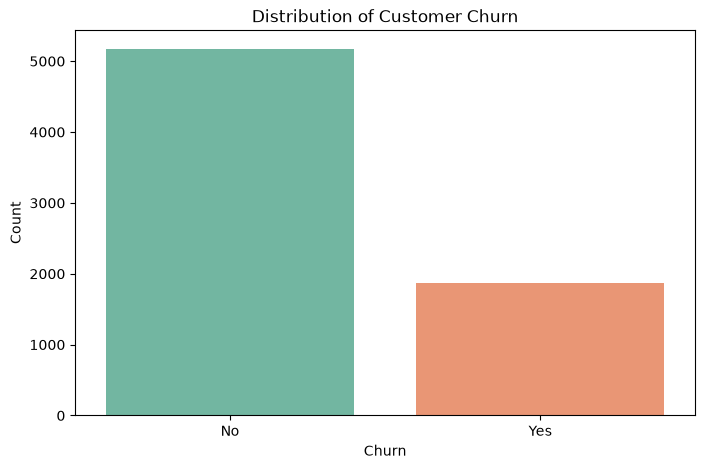

In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Churn", palette="Set2")
plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()


# STEP 4: DATA CLEANING / PREPROCESSING

Data Cleaning makes the dataset more consistent and structured in a way such that the model can easily use it to make predictions. This is where we handle missing values, duplicates, inconsistent data types, and extreme values. 

1. Duplicates 
2. Data Types
3. Extreme Values 
4. Missing Values 

Pro tip: If we don't want to risk tarnishing the original dataset or if we want to rexplore something from a column we may have already dropped, it's best to make a cleaned copy of your DataFrame. 

In [16]:
cleaned_df = df.copy()
print("Original Shape:", cleaned_df.shape)
print("Duplicate Rows:", cleaned_df.duplicated().sum())
cleaned_df = cleaned_df.drop_duplicates()
print("New Shape (after dropping duplicates):", cleaned_df.shape)


Original Shape: (7043, 21)
Duplicate Rows: 0
New Shape (after dropping duplicates): (7043, 21)


In [17]:
cleaned_df["Churn"] = cleaned_df["Churn"].map({"Yes": 1, "No": 0})  # 1 = churned, 0 = stayed
cleaned_df = cleaned_df.drop(columns=["customerID"])
cleaned_df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].head()


,tenure,MonthlyCharges,TotalCharges,Churn
0,1,29.85,29.85,0
1,34,56.95,1889.50,0
2,2,53.85,108.15,1
3,45,42.30,1840.75,0
4,2,70.70,151.65,1


In [18]:
print("Rows with negative tenure:", (cleaned_df["tenure"] < 0).sum())
print("Rows with negative MonthlyCharges:", (cleaned_df["MonthlyCharges"] < 0).sum())
print("Rows with missing TotalCharges:", cleaned_df["TotalCharges"].isnull().sum())
cleaned_df = cleaned_df[cleaned_df["tenure"] >= 0]
cleaned_df.shape


Rows with negative tenure: 0
Rows with negative MonthlyCharges: 0
Rows with missing TotalCharges: 11


(7043, 20)

In [19]:
target_col = "Churn"
print("Missing values before handling:", cleaned_df[target_col].isnull().sum())
cleaned_df = cleaned_df.dropna(subset=[target_col])
print("Missing values after handling:", cleaned_df[target_col].isnull().sum())
print("Cleaned shape:", cleaned_df.shape)


Missing values before handling: 0
Missing values after handling: 0
Cleaned shape: (7043, 20)


In [20]:
for col in cleaned_df.select_dtypes(include="object").columns:
    cleaned_df[col] = cleaned_df[col].astype(str).str.strip()
cleaned_df.head()


/var/folders/td/n6ndsjwd6vd1q3wsmc01f6j80000gn/T/ipykernel_51476/946985698.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in cleaned_df.select_dtypes(include="object").columns:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


# STEP 5: FEATURE ENGINEERING 
When we say "feature engineering", features are our variables (ie. our columns) and engineering those means transforming them in a way such that we can derive patterns from the data. What that entails in the scope of machine learning is that the input variables for the model should be formatted in order for the model to understand them the way a human does, so we are converting our columns to useful features by doing that. 

In [21]:
model_df = cleaned_df.copy()
# avg spend per month over the customer's lifetime
model_df["avg_monthly_charges"] = model_df["TotalCharges"] / (model_df["tenure"] + 1)
model_df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,avg_monthly_charges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,14.925000
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,53.985714
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,36.050000
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,40.016304
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,50.550000


Let's quickly visualize how the feature we created relates to the target variable (Churn) to see if it might be useful for our model:


/var/folders/td/n6ndsjwd6vd1q3wsmc01f6j80000gn/T/ipykernel_51476/1550379612.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=model_df, x="Churn", y="tenure", palette="Set2")


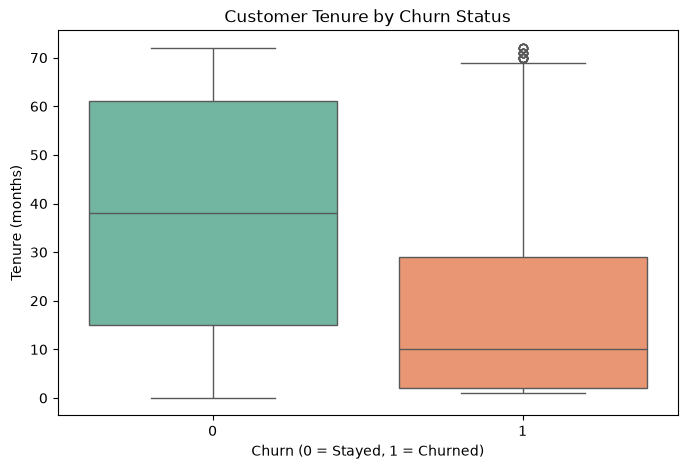

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=model_df, x="Churn", y="tenure", palette="Set2")
plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn (0 = Stayed, 1 = Churned)")
plt.ylabel("Tenure (months)")
plt.show()


# STEP 5.5: FEATURE SELECTION 
Here, our main goal is to just choose the columns that the model will be using. We want to avoid using columns that are overly specific like unique identifier columns, columns that are unavailable at the time of prediction, or columns that are too similar to the actual target. 

In [23]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "SeniorCitizen",
    "avg_monthly_charges"
]

categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

features = numeric_features + categorical_features
target_col = "Churn"

X = model_df[features]
y = model_df[target_col]

print("Feature columns:", features)
print("Target column:", target_col)
print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()


Feature columns: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'avg_monthly_charges', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Target column: Churn
X shape: (7043, 20)
y shape: (7043,)


,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,avg_monthly_charges,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
0,1,29.85,29.85,0,14.925000,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check
1,34,56.95,1889.50,0,53.985714,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check
2,2,53.85,108.15,0,36.050000,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check
3,45,42.30,1840.75,0,40.016304,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic)
4,2,70.70,151.65,0,50.550000,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check


# STEP 6: TRAIN / TEST SPLIT 
Our model needs to be trained on data in order to learn the patterns that exist within it and once we've created our model, we test it with examples of data that it hasn't seen before. In order to do this, we must split our data into "training" and "testing" data, where the training set teaches the model and the testing set estimates how the model will perform on real world / new data. The code for doing this is pretty standardized, a good practice is the 80/20 split (train/test). (Note: don't worry too much about random state, this is something we can leave to abstraction for building ML models)

In [24]:
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("Training target distribution:")
print(y_train.value_counts(normalize=True).round(3))

Training rows: 5634
Testing rows: 1409
Training target distribution:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


# STEP 7: MODEL SELECTION 
We will break this step down a little further into the following: 
1. Preprocessing Pipeline 
2. Establishing a Baseline Model 
3. Model Selection and Training 

### Why does preprocessing matter? 

Raw data is almost never ready for a model to learn from, thus not ready for actual machine learning, which requires numbers. Real datasets often contain one or many of the following which make it unusable to the model: 

- missing values
- text categories
- columns on different scales 
- messy labels 
- irrelevant columns 
- dates 

Preprocessing is the step where we turn the real world data that you'd be given into a format that a machine can more easily read and understand. Here, you'll see we use a 'ColumnTransformer' because different column types need different treatments. 

### What is a pipeline and why does it matter? 

A pipeline essentially means chaining multiple steps together, instead of doing them manually. Here we can put the following into one object: 

1. cleaning data 
2. encoding categories 
3. scaling numbers 
4. training the model

## Preprocessing Pipeline 

We know that machine learning models rely on inputs being quantitative, thus this step of creating a preprocessing pipeline handles both categorial and numeric features. 

1. Numeric features --> fill any missing values left and scale them 
2. Categorical features --> fill any missing values and one-hot encode them 

Question: We know that models need numeric variables so turning categorical features into those is what we call one-hot encoding. Identify a few examples of what columns could be one-hot encoded and HOW to one-hot encode different types of data. 

ANSWER: In our dataset, good examples of columns to one-hot encode are **Contract** (which has 3 values: Month-to-month, One year, Two year → becomes 3 binary columns), **InternetService** (DSL, Fiber optic, No → 3 columns), and **PaymentMethod** (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic) → 4 columns). To one-hot encode, you create one new binary column for each unique category. A row gets a 1 in whichever column matches its category value, and 0 in all the others. For example, a customer with a Month-to-month contract gets [1, 0, 0] across the three contract columns. In sklearn we use `OneHotEncoder()` which handles all of this automatically.


Here, we want to fit preprocessing on the training data only, then apply it to the testing data after. 

**Important Key Terms to Know:** 

imputing: filling missing values with other values in the data (ie filling nan with mean/mode/median)

StandardScalar() --> preprocessing tool from Pipeline to scale numeric variables 

ColumnTransformer() --> does exactly what it sounds like, transforms columns 

OneHotEncoder() --> same thing, one-hot encodes columns 

In [25]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## Baseline Model

Before we train a real model, we want to build a simple baseline model to get us started and then we can tweak each feature weight, hyperparameters, and other metrics accordingly to improve our models accuracy. A baseline model should ideally answer the question of "How well could we do with a simple strategy?". This model will essentially always predict the most common class (making its accuracy the frequency of that class in the data).


In [26]:
baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_preds)

print("Baseline accuracy:", round(baseline_accuracy, 3))
print("Most common class in training data:", y_train.value_counts().idxmax())

Baseline accuracy: 0.735
Most common class in training data: 0



## Model Selection and Training

Here, we will explore three different models and compare their performance to see which one is the best suited for our data. These are three of the most commonly used and simplest machine learning models.

1. Logistic Regression: simple, interpretable classification model
2. Decision Tree: rule-based model that can capture more non linear patterns
3. Random Forest: ensemble of many decision trees, usually stronger but less interpretable

### What is a class imbalance?

Sometimes we'll see one category appear far more than others (ie. if 74% of customers stayed and only 26% churned). A lazy model would predict "no churn" everytime, making it predict based on chance yielding higher accuracy in training but will yield lower accuracy when tested on unseen data! (Hint: DON'T DO THIS)

'class_weight="balanced"' --> tells model to pay more attention to less common classes


In [27]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    
    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
        max_depth=8,
        min_samples_leaf=5
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        max_depth=None,
        min_samples_leaf=2
    ),
    
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=500,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        min_samples_leaf=2
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    
    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}

results = []
trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    acc = accuracy_score(y_test, preds)
    
    trained_pipelines[name] = pipe
    results.append({"model": name, "test_accuracy": acc})

results_df = pd.DataFrame(results).sort_values("test_accuracy", ascending=False)
results_df

,model,test_accuracy
4,Gradient Boosting,0.802697
5,Hist Gradient Boosting,0.791341
2,Random Forest,0.774308
3,Extra Trees,0.757984
0,Logistic Regression,0.743080
1,Decision Tree,0.723208


### Why compare multiple models? 

There is no sinlge best model for each dataset, different models typically learn different patterns in different ways:

Logistic Regression --> learns most linear relationships 
Decision Trees --> learn rule-based splits 
Random Forests --> combine many trees 
Extra Trees --> more randomness 
GRadient Boosting --> builds trees sequentially to fix previous mistakes 

In [28]:
best_model_name = results_df.iloc[0]["model"]
best_model = trained_pipelines[best_model_name]

print("Best model:", best_model_name)

Best model: Gradient Boosting


# STEP 8: MODEL EVALUATION 
This is where we see how well the model performs and where exactly it is failing. Accuracy is a good metric to give us a summary number, but the classification report and confusion matrix show performance by class which is helpful for our non-numeric columns especially. 

In [29]:
test_preds = best_model.predict(X_test)

print("Test accuracy:", round(accuracy_score(y_test, test_preds), 3))
print("Classification report:")
print(classification_report(y_test, test_preds))

Test accuracy: 0.803
Classification report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



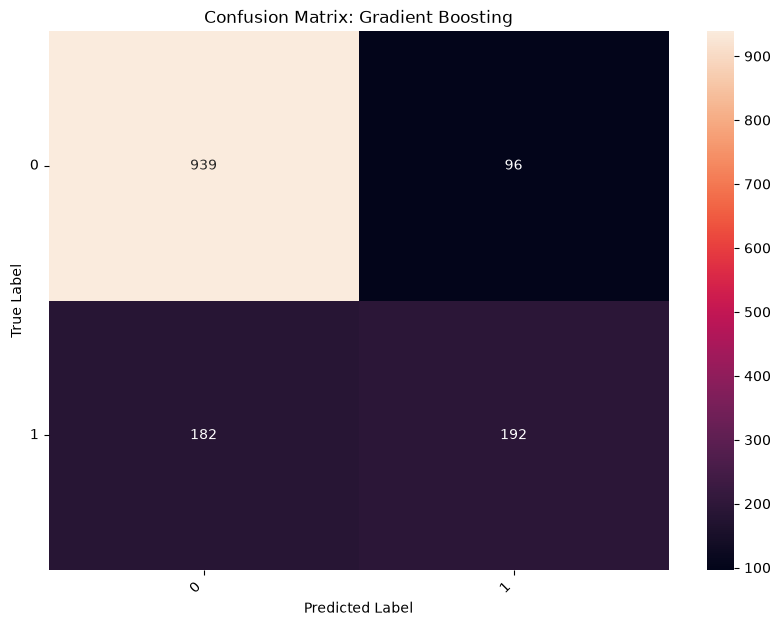

In [30]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, test_preds, labels=labels)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

## Cross-Validation

Cross-Validation gives us a more reliable estimate by training and testing the model several times on different splits of the data. 

5-fold cross-validation:
1. split data into 5 parts 
2. train on 4 parts 
3. test on remaining part 
4. repeat 5 times 
5. average the scores 

### Why one train/test split isn't enough: 

One train/test split can be lucky or unlucky. Cross-validation trains and evaluates the model multiple times on different splits to get a more stable performance estimate.

In [31]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy", n_jobs=-1)
    
    cv_results.append({
        "model": name,
        "mean_cv_accuracy": scores.mean(),
        "std_cv_accuracy": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("mean_cv_accuracy", ascending=False)
cv_results_df

,model,mean_cv_accuracy,std_cv_accuracy
4,Gradient Boosting,0.804201,0.006281
5,Hist Gradient Boosting,0.794971,0.009206
2,Random Forest,0.785316,0.008814
3,Extra Trees,0.767568,0.009551
0,Logistic Regression,0.751667,0.008018
1,Decision Tree,0.719293,0.010626


# Hyperparameter Tuning

A model has two types of settings: 
1. Parameters: these are learned from the data ie. the splits inside a decision tree 

2. Hyperparameters: these settings we choose before training. Grid search tries combinations of settings and uses cross-validation to find the best one.

Examples: 
- number of trees 
- max tree depth 
- minimum samples per leaf 
- max number of features considered at each split 

In [32]:
tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced"))
])

param_grid = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [None, 10],
    "model__min_samples_leaf": [1, 4],
    "model__max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    tuning_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", round(grid_search.best_score_, 3))

final_model = grid_search.best_estimator_


Best parameters: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 300}
Best CV accuracy: 0.79


In [33]:
final_preds = final_model.predict(X_test)

print("Final tuned model test accuracy:", round(accuracy_score(y_test, final_preds), 3))
print()
print("Final tuned model classification report:")
print(classification_report(y_test, final_preds))

Final tuned model test accuracy: 0.783

Final tuned model classification report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409



## Model Interpretability 

A model's accuracy tells us how well it performs, feature importance helps us understand why. For tree-based models, feature importance estimates which variables were most useful for making predictions. 

In [34]:
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()
importances = final_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(20)


,feature,importance
0,num__tenure,0.116500
2,num__TotalCharges,0.115954
4,num__avg_monthly_charges,0.104659
1,num__MonthlyCharges,0.101625
37,cat__Contract_Month-to-month,0.067403
19,cat__OnlineSecurity_No,0.036861
28,cat__TechSupport_No,0.032382
39,cat__Contract_Two year,0.032038
44,cat__PaymentMethod_Electronic check,0.026892
17,cat__InternetService_Fiber optic,0.024460


## Error Analysis 

Accuracy tells us how often the model is correct while error analysis tells us where the model is going wrong. This one is the most important in real world DSML skills because improving a model can only happen when you identify and combat it's errors! 

In [35]:
errors = X_test.copy()
errors["actual"] = y_test.values
errors["predicted"] = final_preds

errors = errors[errors["actual"] != errors["predicted"]]
errors.head(20)

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,avg_monthly_charges,gender,Partner,Dependents,PhoneService,MultipleLines,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,actual,predicted
2280,8,100.15,908.55,1,100.950000,Female,No,No,Yes,Yes,...,No,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),0,1
1639,17,45.05,770.60,1,42.811111,Male,No,No,Yes,No,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,1,0
2136,15,91.00,1430.05,0,89.378125,Male,No,Yes,Yes,Yes,...,Yes,No,No,Yes,No,Month-to-month,Yes,Electronic check,0,1
2488,31,55.25,1715.65,0,53.614063,Male,No,No,Yes,No,...,No,Yes,Yes,No,No,Month-to-month,Yes,Electronic check,1,0
2519,2,91.45,171.45,0,57.150000,Male,Yes,No,Yes,Yes,...,No,Yes,No,Yes,No,Month-to-month,Yes,Electronic check,0,1
523,23,75.60,1758.60,0,73.275000,Female,No,No,Yes,Yes,...,No,No,No,No,No,Month-to-month,No,Bank transfer (automatic),1,0
6304,9,77.65,714.15,0,71.415000,Female,No,No,Yes,No,...,No,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),1,0
5086,45,20.40,930.45,0,20.227174,Male,No,No,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Electronic check,1,0
3408,4,50.70,151.30,0,30.260000,Female,No,No,Yes,No,...,Yes,No,No,No,No,Month-to-month,No,Credit card (automatic),1,0
7011,4,60.40,272.15,0,54.430000,Female,No,No,Yes,No,...,Yes,No,Yes,No,No,Month-to-month,Yes,Mailed check,1,0


## Congrats! 

By this point you would have completed the entire ML process end-to-end! At this point in your project, you client would be looking for you to showcase all the insights this model provided about the data and concurrently how the business should respond, adjust, or pivot based on these insights. Take this huge win of building a model and turn it into another question --> "How would a company or business benefit from a model like this?" 